In [1]:
%pip install pandas numpy openpyxl
%pip install seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
file_path = 'Soya data (1).xlsx'
df = pd.read_excel(file_path)
df.head()

,Farmer Gender,What is your Household Size?,Do you belong to any cooperatives,soyabean2025,What was the total farm size cultivated for Soybean in 2025 (ha)?,Which crops were grown together?,Soya_harvest2025,Fertilizer_Soybean2025,OPV_soya2025(kg),HybridSoy2025(kg),...,What are the challenges you faced during your planting this year?,What are the challenges you faced during your planting this year?/Low access to finance,What are the challenges you faced during your planting this year?/Rainfall,What are the challenges you faced during your planting this year?/Insecurity,What are the challenges you faced during your planting this year?/Pest infestation,What are the challenges you faced during your planting this year?/Low access to farmlands,What are the challenges you faced during your planting this year?/Others,What is the major challenge of rain you faced during your planting this year?,mech2026,Select your code
0,Male,40,No,0,NaN,Maize Sorghum,NaN,NaN,NaN,NaN,...,Insecurity Rainfall Low access to farmlands Ot...,0,1,1,0,1,1,Insufficient or Delayed Rainfall,Yes,NaN
1,Male,22,Yes,1,8.000000e+00,Soybean Sorghum,3.0,NaN,56.0,NaN,...,Pest infestation,0,0,0,1,0,0,NaN,Yes,NaN
2,Male,5,Yes,1,1.000000e+00,Soybean Maize,10.0,5.0,NaN,NaN,...,Low access to finance Rainfall,1,1,0,0,0,0,Insufficient or Delayed Rainfall,No,NaN
3,Male,6,Yes,1,1.000000e+00,Maize Soybean,31.0,3.0,NaN,NaN,...,Low access to finance,1,0,0,0,0,0,NaN,No,AN002
4,Male,5,No,1,8.028153e+09,NaN,18.0,3.0,NaN,NaN,...,Rainfall Others,0,1,0,0,0,1,Insufficient or Delayed Rainfall,No,PD004


In [5]:
df_soya = df[['What is your Household Size?', 'What was the total  farm size cultivated for Soybean in 2025 (ha)?', 'Which crops were grown together?', 'Soya_harvest2025', 'Fertilizer_Soybean2025', 'OPV_soya2025(kg)', 'HybridSoy2025(kg)', 'HerbSoy2025_bottles', 'pesticide_Soybean2025', 'Did you use machinery for planting in 2025']]

In [6]:
df_soya.head(5)

,What is your Household Size?,What was the total farm size cultivated for Soybean in 2025 (ha)?,Which crops were grown together?,Soya_harvest2025,Fertilizer_Soybean2025,OPV_soya2025(kg),HybridSoy2025(kg),HerbSoy2025_bottles,pesticide_Soybean2025,Did you use machinery for planting in 2025
0,40,NaN,Maize Sorghum,NaN,NaN,NaN,NaN,NaN,NaN,Yes
1,22,8.000000e+00,Soybean Sorghum,3.0,NaN,56.0,NaN,NaN,55.0,Yes
2,5,1.000000e+00,Soybean Maize,10.0,5.0,NaN,NaN,NaN,NaN,No
3,6,1.000000e+00,Maize Soybean,31.0,3.0,NaN,NaN,5.0,NaN,No
4,5,8.028153e+09,NaN,18.0,3.0,NaN,NaN,NaN,NaN,No


In [7]:
df_soya.info()

<class 'pandas.DataFrame'>
RangeIndex: 4110 entries, 0 to 4109
Data columns (total 10 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   What is your Household Size?                                        4110 non-null   int64  
 1   What was the total  farm size cultivated for Soybean in 2025 (ha)?  2345 non-null   float64
 2   Which crops were grown together?                                    601 non-null    str    
 3   Soya_harvest2025                                                    2345 non-null   float64
 4   Fertilizer_Soybean2025                                              1918 non-null   float64
 5   OPV_soya2025(kg)                                                    2040 non-null   float64
 6   HybridSoy2025(kg)                                                   1941 non-null   float64
 7   HerbSoy2025_bottles       

In [8]:
df_soya = pd.get_dummies(df_soya, columns = ['Which crops were grown together?', 'Did you use machinery for planting in 2025'], prefix = ['Intercrop', 'Machinery'], drop_first = True)

df_soya.head(5)

,What is your Household Size?,What was the total farm size cultivated for Soybean in 2025 (ha)?,Soya_harvest2025,Fertilizer_Soybean2025,OPV_soya2025(kg),HybridSoy2025(kg),HerbSoy2025_bottles,pesticide_Soybean2025,Intercrop_Maize Sesame,Intercrop_Maize Sorghum,Intercrop_Maize Soybean,Intercrop_Maize Soybean Sorghum,Intercrop_Paddy rice Soybean,Intercrop_Sorghum Maize,Intercrop_Sorghum Soybean,Intercrop_Soybean Maize,Intercrop_Soybean Paddy rice,Intercrop_Soybean Sorghum,Machinery_Yes
0,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,False,False,False,False,False,False,False,True
1,22,8.000000e+00,3.0,NaN,56.0,NaN,NaN,55.0,False,False,False,False,False,False,False,False,False,True,True
2,5,1.000000e+00,10.0,5.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,True,False,False,False
3,6,1.000000e+00,31.0,3.0,NaN,NaN,5.0,NaN,False,False,True,False,False,False,False,False,False,False,False
4,5,8.028153e+09,18.0,3.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False


In [9]:
columns_drop = ['Intercrop_Maize Sesame', 'Intercrop_Maize Sorghum', 'Intercrop_Sorghum Maize']

df_soya = df_soya.drop(columns = columns_drop)
df_soya.head(5)

,What is your Household Size?,What was the total farm size cultivated for Soybean in 2025 (ha)?,Soya_harvest2025,Fertilizer_Soybean2025,OPV_soya2025(kg),HybridSoy2025(kg),HerbSoy2025_bottles,pesticide_Soybean2025,Intercrop_Maize Soybean,Intercrop_Maize Soybean Sorghum,Intercrop_Paddy rice Soybean,Intercrop_Sorghum Soybean,Intercrop_Soybean Maize,Intercrop_Soybean Paddy rice,Intercrop_Soybean Sorghum,Machinery_Yes
0,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,True
1,22,8.000000e+00,3.0,NaN,56.0,NaN,NaN,55.0,False,False,False,False,False,False,True,True
2,5,1.000000e+00,10.0,5.0,NaN,NaN,NaN,NaN,False,False,False,False,True,False,False,False
3,6,1.000000e+00,31.0,3.0,NaN,NaN,5.0,NaN,True,False,False,False,False,False,False,False
4,5,8.028153e+09,18.0,3.0,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False


In [10]:
df_soya.info()

<class 'pandas.DataFrame'>
RangeIndex: 4110 entries, 0 to 4109
Data columns (total 16 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   What is your Household Size?                                        4110 non-null   int64  
 1   What was the total  farm size cultivated for Soybean in 2025 (ha)?  2345 non-null   float64
 2   Soya_harvest2025                                                    2345 non-null   float64
 3   Fertilizer_Soybean2025                                              1918 non-null   float64
 4   OPV_soya2025(kg)                                                    2040 non-null   float64
 5   HybridSoy2025(kg)                                                   1941 non-null   float64
 6   HerbSoy2025_bottles                                                 1121 non-null   float64
 7   pesticide_Soybean2025     

In [ ]:

df_soya['Intercrop_Maize_Soybean'] = df_soya['Intercrop_Maize Soybean'] | df_soya['Intercrop_Soybean Maize']
df_soya['Intercrop_Paddy_rice_Soybean'] = df_soya['Intercrop_Paddy rice Soybean'] | df_soya['Intercrop_Soybean Paddy rice']
df_soya['Intercrop_Sorghum_Soybean'] = df_soya['Intercrop_Sorghum Soybean'] | df_soya['Intercrop_Soybean Sorghum']

df_soya = df_soya.drop(columns=[
    'Intercrop_Maize Soybean', 'Intercrop_Soybean Maize',
    'Intercrop_Paddy rice Soybean', 'Intercrop_Soybean Paddy rice',
    'Intercrop_Sorghum Soybean', 'Intercrop_Soybean Sorghum'
])

In [12]:
df_soya.head(5)

,What is your Household Size?,What was the total farm size cultivated for Soybean in 2025 (ha)?,Soya_harvest2025,Fertilizer_Soybean2025,OPV_soya2025(kg),HybridSoy2025(kg),HerbSoy2025_bottles,pesticide_Soybean2025,Intercrop_Maize Soybean Sorghum,Machinery_Yes,Intercrop_Maize_Soybean,Intercrop_Paddy_rice_Soybean,Intercrop_Sorghum_Soybean
0,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,False,False,False
1,22,8.000000e+00,3.0,NaN,56.0,NaN,NaN,55.0,False,True,False,False,True
2,5,1.000000e+00,10.0,5.0,NaN,NaN,NaN,NaN,False,False,True,False,False
3,6,1.000000e+00,31.0,3.0,NaN,NaN,5.0,NaN,False,False,True,False,False
4,5,8.028153e+09,18.0,3.0,NaN,NaN,NaN,NaN,False,False,False,False,False


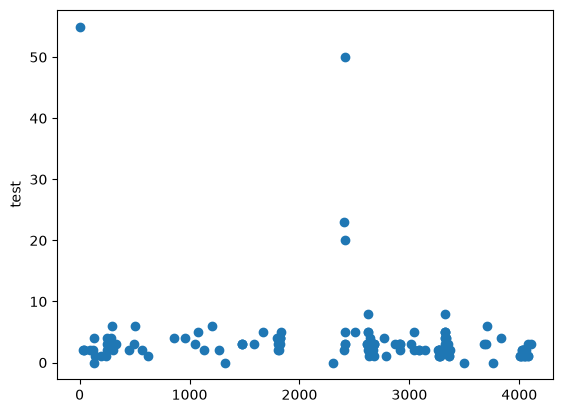

In [21]:
plt.scatter(df_soya.index, df_soya['pesticide_Soybean2025'])
plt.ylabel('test')
plt.show()